# 04 — Diebold–Mariano Tests & Thesis Visuals

DM тесты для всех пар моделей + публикационные графики.

**Требуется**: сначала `main.py`

In [1]:
from pathlib import Path
import sys
ROOT = next(
    str(p) for p in [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]
    if (p / 'config.yaml').exists()
)
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from thesis_app.notebook_helpers import apply_thesis_plot_style, preferred_xgb_label, best_ml_model_name, significance_stars, interpretation_text
apply_thesis_plot_style()


## Interpretation focus
This notebook tests whether forecast improvements are statistically meaningful. On the defense, connect visual fit with formal DM evidence and avoid claiming superiority without significance support.

In [2]:
from pathlib import Path
import sys
ROOT = next(
    str(p) for p in [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]
    if (p / 'config.yaml').exists()
)
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

import sys, os


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from glob import glob

from thesis_app.pipeline import load_config, build_paths, inv_fisher_z, dm_to_latex

%matplotlib inline
plt.rcParams['figure.dpi'] = 110

cfg = load_config(os.path.join(ROOT, 'config.yaml'))
paths = build_paths(ROOT)

csv_files = sorted(glob(os.path.join(paths.predictions, '*_predictions.csv')))
experiments = {
    os.path.basename(f).replace('_predictions.csv', ''): pd.read_csv(f, index_col=0, parse_dates=True)
    for f in csv_files
}
metrics_df = pd.read_csv(os.path.join(paths.results, 'metrics.csv'))
dm_df = pd.read_csv(os.path.join(paths.results, 'dm_tests.csv'))

if 'significant' not in dm_df.columns:
    dm_df['significant'] = dm_df['p_value'].apply(significance_stars)
if 'model_better' not in dm_df.columns:
    dm_df['model_better'] = dm_df['DM_stat'] > 0

print(f'Loaded {len(experiments)} experiments')
print(list(experiments.keys())[:4], '...')
print(f'metrics rows: {len(metrics_df)} | dm rows: {len(dm_df)}')


Loaded 24 experiments
['corr_BTC-USD_ETH-USD_w14_fisher_z', 'corr_BTC-USD_ETH-USD_w30_fisher_z', 'corr_BTC-USD_ETH-USD_w60_fisher_z', 'corr_BTC-USD_ETH-USD_w90_fisher_z'] ...
metrics rows: 192 | dm rows: 240


In [3]:
DM_NW_LAG = int(cfg.get('dm_nw_lag', 0))
preferred_xgb = preferred_xgb_label(metrics_df['model'].unique())
if preferred_xgb is None:
    preferred_xgb = best_ml_model_name(metrics_df)
MODEL_PAIRS = [
    (preferred_xgb, 'DCC_GARCH'),
    (preferred_xgb, 'Naive_Last'),
] if preferred_xgb else []
print('Using ML benchmark:', preferred_xgb)
print(interpretation_text('DM statistic', higher_is_better=True))


Using ML benchmark: XGB_GPU
Interpretation: higher DM statistic indicates stronger practical usefulness in the out-of-sample setting.


In [4]:
ml_label = best_ml_model_name(metrics_df) or preferred_xgb_label(dm_df['model'].unique()) or dm_df['model'].mode().iloc[0]
ml_vs_dcc = dm_df[(dm_df['model'] == ml_label) & (dm_df['benchmark'] == 'DCC_GARCH')].copy()

print(f'{ml_label} vs DCC_GARCH:')
if ml_vs_dcc.empty:
    print('No DM rows found for this comparison.')
else:
    print(ml_vs_dcc[['dependency', 'window', 'DM_stat', 'p_value', 'significant', 'model_better']].to_string(index=False))
    print(f'ML better in {int(ml_vs_dcc["model_better"].sum())}/{len(ml_vs_dcc)} tests')
    print('Interpretation: positive DM statistics with low p-values support economically meaningful forecast gains over DCC-GARCH.')


Ridge vs DCC_GARCH:
          dependency  window   DM_stat       p_value significant  model_better
  corr_BTC-USD_^GSPC      90 23.969595 2.225074e-308         ***          True
  corr_BTC-USD_^GSPC      60 33.256824 2.225074e-308         ***          True
  corr_BTC-USD_^GSPC      30 25.750760 2.225074e-308         ***          True
  corr_BTC-USD_^GSPC      14 22.044691 2.225074e-308         ***          True
  corr_BTC-USD_^IXIC      14 22.236281 2.225074e-308         ***          True
  corr_BTC-USD_^IXIC      30 24.158261 2.225074e-308         ***          True
  corr_BTC-USD_^IXIC      90 19.653852 2.225074e-308         ***          True
  corr_BTC-USD_^IXIC      60 30.196857 2.225074e-308         ***          True
    corr_BTC-USD_GLD      14 19.678167 2.225074e-308         ***          True
    corr_BTC-USD_GLD      90 22.855953 2.225074e-308         ***          True
    corr_BTC-USD_GLD      30 28.440088 2.225074e-308         ***          True
    corr_BTC-USD_GLD      60 28.

C:\Users\Mini-ITX GAMER\AppData\Local\Temp\ipykernel_15148\4103422391.py:41: UserWarning: Glyph 8658 (\N{RIGHTWARDS DOUBLE ARROW}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Mini-ITX GAMER\AppData\Local\Temp\ipykernel_15148\4103422391.py:42: UserWarning: Glyph 8658 (\N{RIGHTWARDS DOUBLE ARROW}) missing from font(s) Arial.
  plt.savefig(os.path.join(paths.figures, f'dm_heatmap_{ml_label}_vs_DCC.png'), dpi=150)
D:\clode9\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8658 (\N{RIGHTWARDS DOUBLE ARROW}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


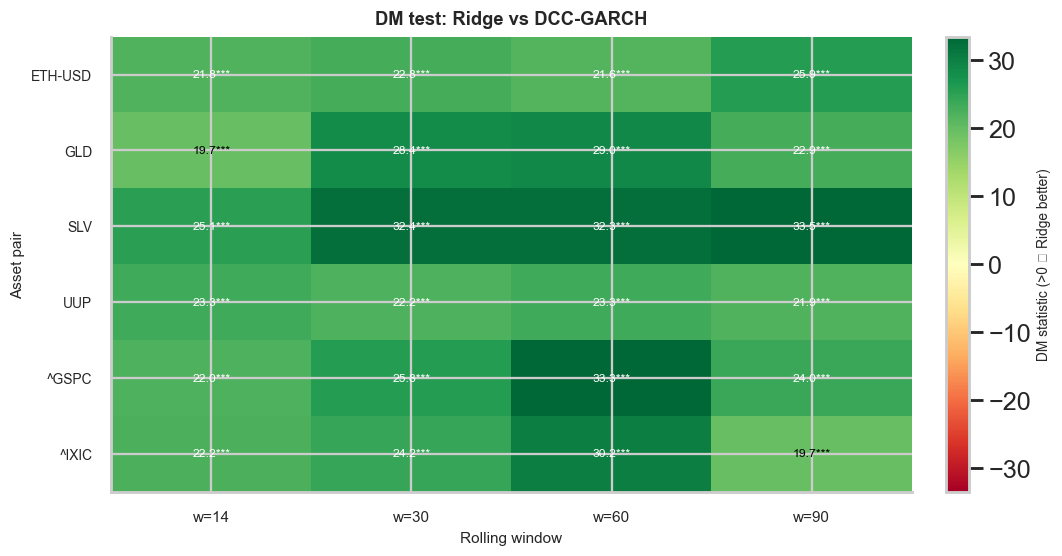

In [5]:
hm = ml_vs_dcc.copy()
hm['pair'] = hm['dependency'].str.replace('corr_BTC-USD_', '', regex=False)

if hm.empty:
    print('Heatmap skipped: no DM results for ML vs DCC.')
else:
    pivot_dm = hm.pivot_table(index='pair', columns='window', values='DM_stat', aggfunc='first')
    vals = pivot_dm.values.astype(float)
    # Cap colour range at 99th percentile to avoid outlier saturation
    finite_vals = vals[np.isfinite(vals)]
    vmax = float(np.percentile(np.abs(finite_vals), 99)) if len(finite_vals) else 5.0
    vmax = max(vmax, 5.0)

    fig, ax = plt.subplots(figsize=(10, max(4, len(pivot_dm) * 0.9)))
    im = ax.imshow(vals, cmap='RdYlGn', vmin=-vmax, vmax=vmax, aspect='auto')

    ax.set_xticks(range(len(pivot_dm.columns)))
    ax.set_xticklabels([f'w={w}' for w in pivot_dm.columns], fontsize=10)
    ax.set_yticks(range(len(pivot_dm.index)))
    ax.set_yticklabels(pivot_dm.index, fontsize=9)

    # Annotate cells with DM stat + significance stars
    for i in range(len(pivot_dm.index)):
        for j in range(len(pivot_dm.columns)):
            v = vals[i, j]
            if np.isnan(v):
                # Show a dash for missing combinations
                ax.text(j, i, '—', ha='center', va='center', fontsize=9, color='#888888')
                continue
            sig_rows = hm[(hm['pair'] == pivot_dm.index[i]) & (hm['window'] == pivot_dm.columns[j])]['significant']
            star = sig_rows.values[0] if len(sig_rows) > 0 else ''
            brightness = abs(v) / vmax
            txt_color = 'white' if brightness > 0.6 else 'black'
            ax.text(j, i, f'{v:.1f}{star}', ha='center', va='center', fontsize=8, color=txt_color)

    cbar = plt.colorbar(im, ax=ax, fraction=0.035, pad=0.04)
    cbar.set_label(f'DM statistic (>0 ⇒ {ml_label} better)', fontsize=9)
    ax.set_xlabel('Rolling window', fontsize=10)
    ax.set_ylabel('Asset pair', fontsize=10)
    ax.set_title(f'DM test: {ml_label} vs DCC-GARCH', fontsize=12, pad=8)
    plt.tight_layout()
    plt.savefig(os.path.join(paths.figures, f'dm_heatmap_{ml_label}_vs_DCC.png'), dpi=150)
    plt.show()

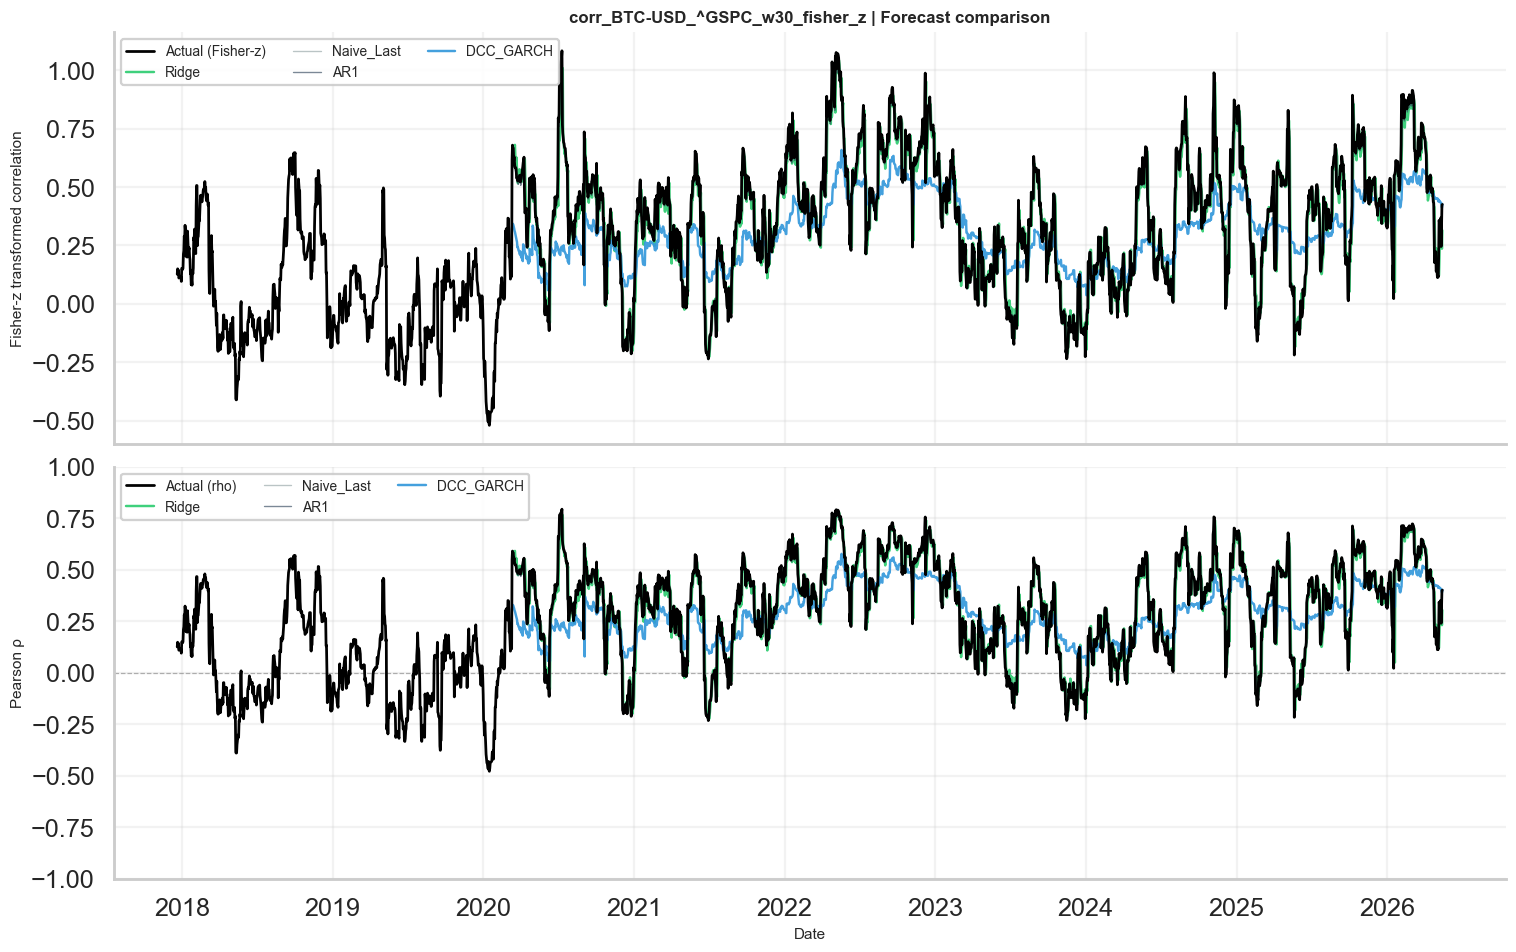

Saved.
Interpretation: compare whether the preferred ML model tracks turning points earlier than DCC and whether both outperform naive persistence only marginally or materially.


In [6]:
SHOWCASE = 'corr_BTC-USD_^GSPC_w30_fisher_z'
if SHOWCASE not in experiments:
    SHOWCASE = list(experiments.keys())[0]
    print(f'Using: {SHOWCASE}')

df = experiments[SHOWCASE]
y_true = df['y_true']
showcase_dependency = SHOWCASE.split('_w')[0]
showcase_window = int(SHOWCASE.split('_w')[1].split('_')[0])
show_metrics = metrics_df[(metrics_df['dependency'] == showcase_dependency) & (metrics_df['window'] == showcase_window)].copy()
preferred_ml = best_ml_model_name(show_metrics) or preferred_xgb_label(df.columns)
plot_models = ['Naive_Last', 'AR1', 'DCC_GARCH']
if preferred_ml:
    plot_models.insert(0, preferred_ml)
plot_models = [m for m in plot_models if m in df.columns and df[m].notna().sum() > 50]

COLORS = {
    'XGB_GPU': '#e74c3c', 'XGB_CPU': '#e74c3c', 'DCC_GARCH': '#3498db',
    'Ridge': '#2ecc71', 'Naive_Last': '#95a5a6', 'RF': '#9b59b6',
    'GBM': '#e67e22', 'AR1': '#34495e', 'ElasticNet': '#16a085'
}
# Human-readable legend labels
LABELS = {
    'XGB_GPU': 'XGB', 'XGB_CPU': 'XGB', 'DCC_GARCH': 'DCC_GARCH',
    'Ridge': 'Ridge', 'Naive_Last': 'Naive_Last', 'RF': 'RF',
    'GBM': 'GBM', 'AR1': 'AR1', 'ElasticNet': 'ElasticNet',
}

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

# ── Top panel: Fisher-z space ─────────────────────────────────────────
ax = axes[0]
ax.plot(y_true.index, y_true, label='Actual (Fisher-z)', color='black', lw=1.8, zorder=5)
for model in plot_models:
    is_key = model in {preferred_ml, 'DCC_GARCH'}
    ax.plot(df.index, df[model],
            label=LABELS.get(model, model),
            color=COLORS.get(model, 'gray'),
            lw=1.6 if is_key else 0.9,
            alpha=0.92 if is_key else 0.65)
ax.set_ylabel('Fisher-z transformed correlation', fontsize=10)
ax.set_title(f'corr_BTC-USD_^GSPC_w30_fisher_z | Forecast comparison', fontsize=11, pad=6)
ax.legend(ncol=3, fontsize=9, loc='upper left', framealpha=0.9)
ax.grid(alpha=0.25)

# ── Bottom panel: Pearson ρ space ─────────────────────────────────────
ax2 = axes[1]
ax2.plot(y_true.index, inv_fisher_z(y_true), label='Actual (rho)', color='black', lw=1.8, zorder=5)
for model in plot_models:
    is_key = model in {preferred_ml, 'DCC_GARCH'}
    ax2.plot(df.index, inv_fisher_z(df[model]),
             label=LABELS.get(model, model),
             color=COLORS.get(model, 'gray'),
             lw=1.6 if is_key else 0.9,
             alpha=0.92 if is_key else 0.65)
ax2.axhline(0, color='gray', lw=0.8, ls='--', alpha=0.6)
ax2.set_ylabel('Pearson ρ', fontsize=10)
ax2.set_xlabel('Date', fontsize=10)
ax2.legend(ncol=3, fontsize=9, loc='upper left', framealpha=0.9)
ax2.grid(alpha=0.25)
ax2.set_ylim(-1, 1)

plt.tight_layout(h_pad=0.5)
plt.savefig(os.path.join(paths.figures, f'thesis_forecast_{SHOWCASE}.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved.')
print('Interpretation: compare whether the preferred ML model tracks turning points earlier than DCC and whether both outperform naive persistence only marginally or materially.')

In [7]:
summary = dm_df.groupby(['model', 'benchmark']).agg(
    n_tests=('DM_stat', 'count'),
    n_sig=('significant', lambda x: (x != '').sum()),
    n_better=('model_better', 'sum'),
    mean_DM=('DM_stat', 'mean'),
).round(3)
print('DM summary:')
print(summary.to_string())

tex_path = os.path.join(paths.tables, 'dm_tests_full.tex')
dm_to_latex(dm_df, tex_path)
print(f'LaTeX saved: {tex_path}')
print('DM tests complete.')


DM summary:
                       n_tests  n_sig  n_better  mean_DM
model      benchmark                                    
ElasticNet DCC_GARCH        24     24        24   25.388
           Naive_Last       24     24         0  -10.588
GBM        DCC_GARCH        24     24        24   25.276
           Naive_Last       24     24         0  -12.594
RF         DCC_GARCH        24     24        24   24.963
           Naive_Last       24     24         0  -12.791
Ridge      DCC_GARCH        24     24        24   25.298
           Naive_Last       24     24         0  -10.286
XGB_GPU    DCC_GARCH        24     24        24   25.122
           Naive_Last       24     24         0  -13.319
LaTeX saved: D:\clear\outputs\tables\dm_tests_full.tex
DM tests complete.
